<a href="https://colab.research.google.com/github/CodexAarogya/Fusemachines-Assignments/blob/main/NaturalLanguageProcessing/WNUT_17_Emerging_Entities.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn sklearn-crfsuite matplotlib -q

In [ ]:
!pip install "datasets<4.0.0"

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from sklearn.metrics import classification_report
import sklearn_crfsuite
from sklearn_crfsuite import metrics
import seaborn as sns

# Set matplotlib style for clean visualiztions
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [ ]:
# Importing data

import pandas as pd

dataset = load_dataset("manu/wnut_17")

In [ ]:
# Inspecting the structure of dataset

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 3394
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1009
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1287
    })
})

In [ ]:
#Inspecting Entity of dataset

ENTITY_LABELS = dataset['train'].features['ner_tags'].feature.names
print(f"Entity labels: {ENTITY_LABELS}")

Entity labels: ['O', 'B-corporation', 'I-corporation', 'B-creative-work', 'I-creative-work', 'B-group', 'I-group', 'B-location', 'I-location', 'B-person', 'I-person', 'B-product', 'I-product']


### Inspecting sample sentence along with it's entity label

In [ ]:
# Fetch a sample sentence
sample_idx = 43

sample_tokens = dataset['train'][sample_idx]['tokens']
sample_ner_ids = dataset['train'][sample_idx]['ner_tags']

# Convert label IDs back to human-readable string labels
sample_ner_labels = [ENTITY_LABELS[tag] for tag in sample_ner_ids]

print(f"{'Token':<15} | {'NER Tag':<10}")
print("-" * 30)
for token, label in zip(sample_tokens, sample_ner_labels):
    print(f"{token:<15} | {label:<10}")

Token           | NER Tag   
------------------------------
i               | O         
want            | O         
a               | O         
bath            | O         
but             | O         
do              | O         
n't             | O         
have            | O         
a               | O         
bath            | O         
,               | O         
shut            | O         
up              | O         
,               | O         
sam             | B-person  
's              | O         
coming          | O         
tomorrow        | O         
and             | O         
steve           | B-person  
and             | O         
tanya           | B-person  
will            | O         
be              | O         
round           | O         
at              | O         
10am            | O         
so              | O         
go              | O         
away            | O         
you             | O         
mean            | O         
people      

### Analysing how tokens are stored to get an intuition about sentence length

In [ ]:
dataset['train']['tokens'][:2]

[['@paulwalk',
  'It',
  "'s",
  'the',
  'view',
  'from',
  'where',
  'I',
  "'m",
  'living',
  'for',
  'two',
  'weeks',
  '.',
  'Empire',
  'State',
  'Building',
  '=',
  'ESB',
  '.',
  'Pretty',
  'bad',
  'storm',
  'here',
  'last',
  'evening',
  '.'],
 ['From',
  'Green',
  'Newsfeed',
  ':',
  'AHFA',
  'extends',
  'deadline',
  'for',
  'Sage',
  'Award',
  'to',
  'Nov',
  '.',
  '5',
  'http://tinyurl.com/24agj38']]

In [ ]:
# Calculate dataset statistics
train_sentences = dataset['train']['tokens']    # this contains info like [ [s1_tokens], [s2_tokens], .....[sn_tokens]]
val_sentences = dataset['validation']['tokens']
test_sentences = dataset['test']['tokens']

# Sentence Lengths
train_lengths = [len(sentence) for sentence in train_sentences]  # now we loop inside tokens of each sentence to get length of particular sentence.

# Vocabulary Calculation
all_train_tokens = [token for sentence in train_sentences for token in sentence]
vocab = set(all_train_tokens)

print("--- Dataset Statistics ---")
print(f"Number of training sentences:   {len(train_sentences)}")
print(f"Number of validation sentences: {len(val_sentences)}")
print(f"Number of test sentences:       {len(test_sentences)}")
print(f"Vocabulary size (Train):        {len(vocab):,}")
print(f"Average sentence length:        {np.mean(train_lengths):.2f} tokens")
print(f"Maximum sentence length:        {np.max(train_lengths)} tokens")
print(f"Minimum sentence length:        {np.min(train_lengths)} tokens")


--- Dataset Statistics ---
Number of training sentences:   3394
Number of validation sentences: 1009
Number of test sentences:       1287
Vocabulary size (Train):        14,878
Average sentence length:        18.48 tokens
Maximum sentence length:        41 tokens
Minimum sentence length:        1 tokens


## Data Visualizaton

We will use `matplotlib` to plot three key aspects of our data:
1. **Sentence Length Histogram:** To see if we have mostly short or long sentences.
2. **Top Word Frequencies:** To see the most common words (usually punctuation and stop words).
3. **Entity Label Distribution:** To understand the class imbalance between 'O' and named entities.

### Word Cloud of Most Frequent Words

A word cloud visually represents the frequency of words in a text corpus. The larger the word appears, the more frequently it occurs in the dataset. This can help in quickly identifying prominent terms.

In [ ]:
# Install wordcloud library if not already installed
!pip install wordcloud -q

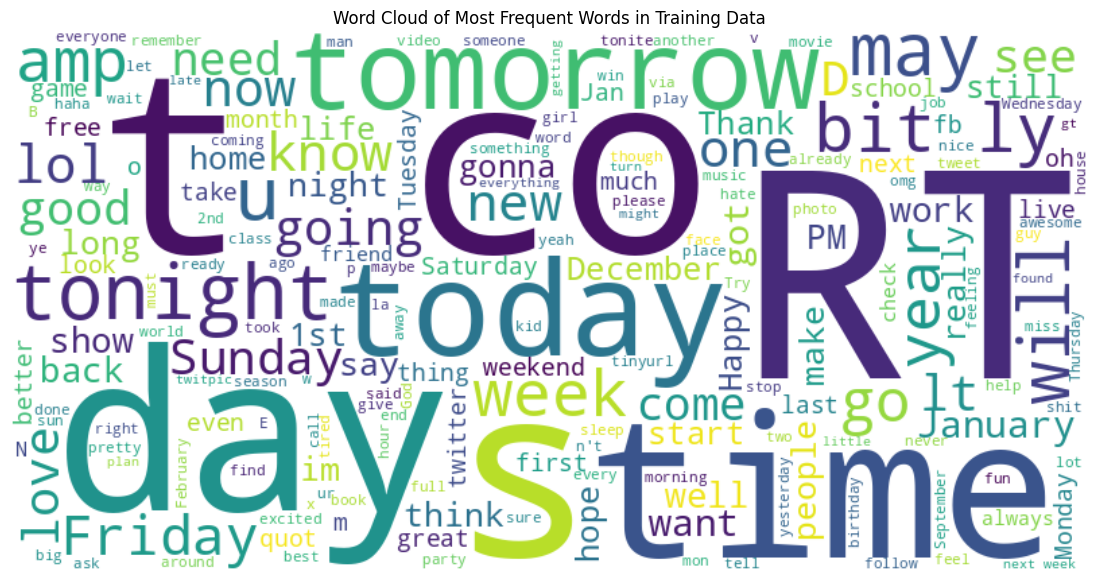

In [ ]:
from wordcloud import WordCloud

# Join all training tokens into a single string
text = " ".join(all_train_tokens)

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the generated image:
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words in Training Data')
plt.show()

### Conclusion on Word Cloud

The word cloud effectively highlights the most prominent terms in the training data, offering a quick visual summary of the corpus's thematic content. This can be useful for initial data exploration and understanding the general vocabulary of the dataset.

## Analysing Sentence Length using Histogram

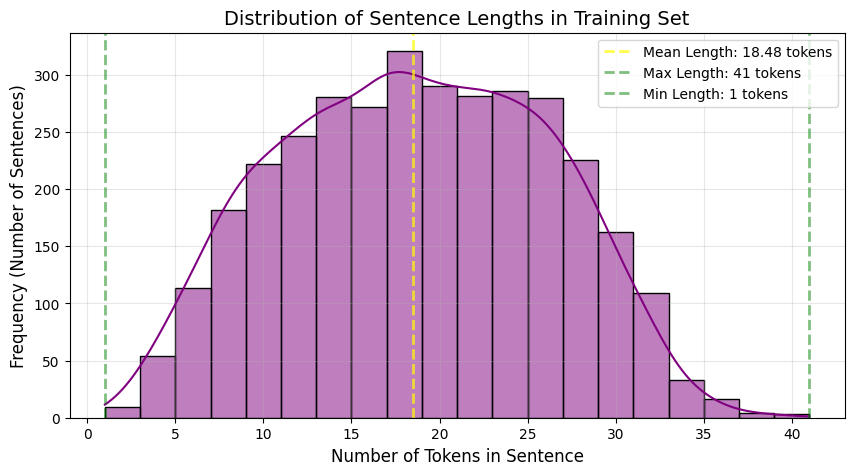

In [ ]:
# 1. Sentence Length Histogram
plt.figure(figsize=(10, 5))
sns.histplot(train_lengths, bins=20, kde=True, color='purple')
plt.title("Distribution of Sentence Lengths in Training Set", fontsize=14)
plt.xlabel("Number of Tokens in Sentence", fontsize=12)
plt.ylabel("Frequency (Number of Sentences)", fontsize=12)

plt.axvline(np.mean(train_lengths), color='yellow', linestyle='dashed', linewidth=2,
            label=f'Mean Length: {np.mean(train_lengths):.2f} tokens', alpha=.7)

plt.axvline(np.max(train_lengths), color='green', linestyle='dashed', linewidth=2,
            label=f'Max Length: {np.max(train_lengths)} tokens', alpha=.5)

plt.axvline(np.min(train_lengths), color='green', linestyle='dashed', linewidth=2,
            label=f'Min Length: {np.min(train_lengths)} tokens', alpha=.5)

plt.legend()
plt.show()

### Conclusion on Sentence Length Distribution

The histogram for sentence lengths reveals that the training dataset primarily consists of shorter sentences. With an average length of **18.48 token(s)**, a minimum of **1 token(s)**, and a maximum of **41 token(s)**, it indicates a dataset with generally concise text segments. This distribution is important for model design, especially concerning sequence lengths in neural network architectures.

## Analysing top 30 most frequent words

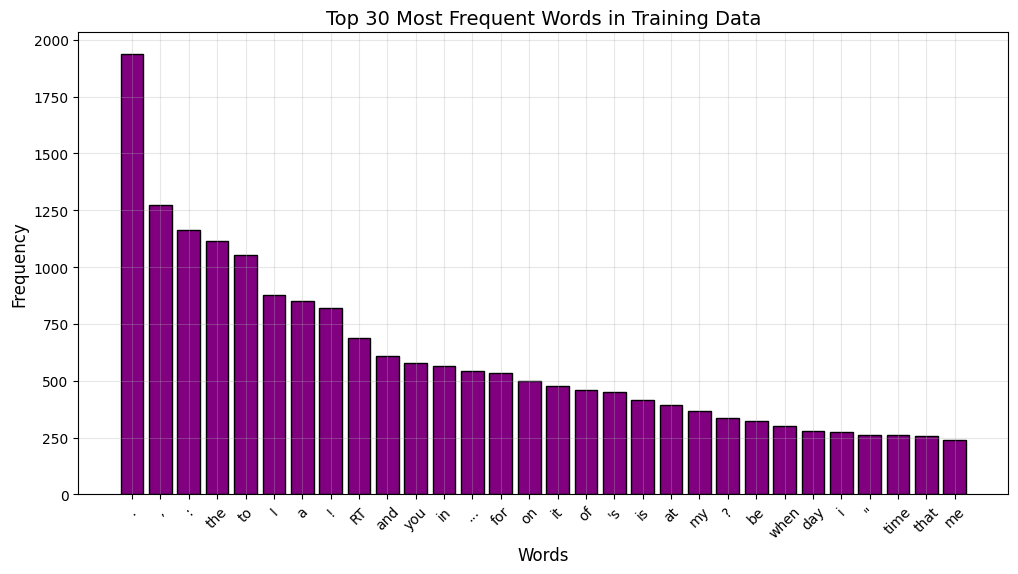

In [ ]:
# 2. Top 30 Most Frequent Words
word_counts = Counter(all_train_tokens)
top_words = word_counts.most_common(30)

words, counts = zip(*top_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='purple', edgecolor='black')
plt.title("Top 30 Most Frequent Words in Training Data", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Conclusion on Top 30 Most Frequent Words

The analysis of the top 30 most frequent words reveals a common pattern in text datasets: the most frequent words are often 'noise' such as punctuation marks (e.g., '.', ',', ':') and common stop words (e.g., 'the', 'to', 'a', 'I', 'and'). This is an expected outcome, as these elements appear frequently across almost all natural language texts. For tasks like named entity recognition, these high-frequency words typically carry less semantic weight regarding entity identification and might be filtered out or handled specifically during preprocessing.

## Analysing top 30 least common words

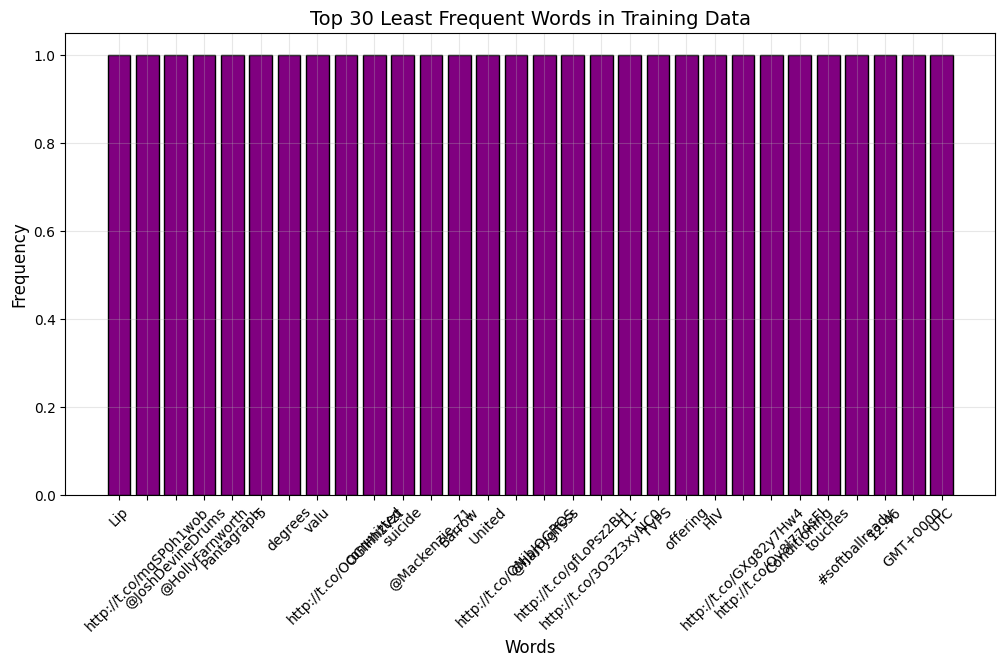

In [ ]:
# 3. Top 30 Least Frequent Words
word_counts = Counter(all_train_tokens)

least_common_words = word_counts.most_common()[-30:]

words, counts = zip(*least_common_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='purple', edgecolor='black')
plt.title("Top 30 Least Frequent Words in Training Data", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Conclusion on Top 30 Least Frequent Words

The analysis of the least frequent words reveals terms that appear only once or very rarely in the dataset. As observed from the graph, these often include URLs, usernames (e.g., `@JoshDevineDrums`), hashtags, specific proper nouns, or time-related data (e.g., '12:46', 'GMT+0000', 'UTC'). While less frequent, these words can sometimes be crucial for identifying rare entities or understanding nuanced contexts, but they also highlight potential data sparsity issues for models that rely on word frequency.

## Top Entity labels (excluding `O`)

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 3394
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1009
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 1287
    })
})

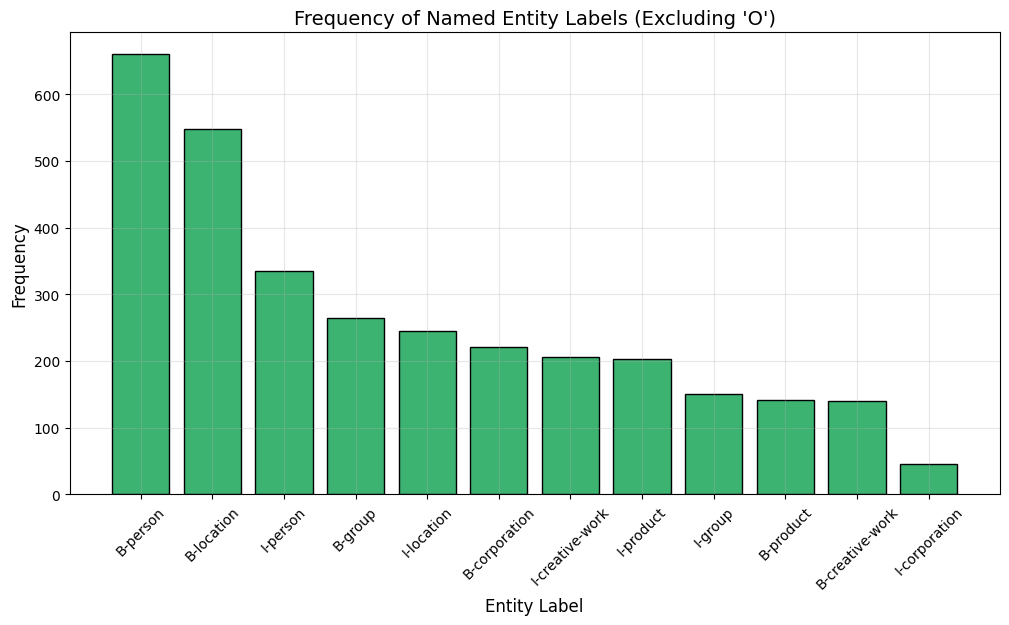

In [ ]:
# 4. Top Entity Labels (Excluding 'O')
all_train_labels = [ENTITY_LABELS[tag] for sentence in dataset['train']['ner_tags'] for tag in sentence]
label_counts = Counter(all_train_labels)

# Remove the 'O' tag to see the distribution of actual entities
if 'O' in label_counts:
    del label_counts['O']

# Sort by frequency
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_labels)

plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color='mediumseagreen', edgecolor='black')
plt.title("Frequency of Named Entity Labels (Excluding 'O')", fontsize=14)
plt.xlabel("Entity Label", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Conclusion on Named Entity Label Distribution

The bar chart illustrating the frequency of named entity labels (excluding 'O' for 'Outside') provides insight into the distribution of different entity types within the training data. We observe that `B-person` and `B-location` are the most frequent entity types, followed by `I-person`, `B-group`, and `I-location`. This distribution highlights the types of entities most commonly annotated in this dataset, which is crucial for understanding the focus of the NER task and for evaluating potential class imbalance among specific entity types during model training.

## Feature Engineering

In [ ]:
# Feature extraction function for a single token
def word2features(sentence, i):
    word = sentence[i]

    # Core word-level features
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],      # 3-character suffix (e.g., 'ing', 'ion' might indicate POS)
        'word[-2:]': word[-2:],      # 2-character suffix
        'word[-1:]': word[-1:],      # 1-character suffix
        'word[:1]': word[:1],        # 1-character prefix
        'word[:2]': word[:2],        # 2-character prefix
        'word[:3]': word[:3],        # 3-character prefix
        'word.isupper()': word.isupper(), # e.g., IBM, USA
        'word.istitle()': word.istitle(), # e.g., John, London
        'word.isdigit()': word.isdigit(), # e.g., 1999
    }

    # Features for the PREVIOUS word (Context)
    if i > 0:
        word1 = sentence[i-1]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True # Beginning of Sentence indicator

    # Features for the NEXT word (Context)
    if i < len(sentence)-1:
        word1 = sentence[i+1]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True # End of Sentence indicator

    return features

# Helper functions to apply feature extraction to entire sentences
def sent2features(sentence):
    return [word2features(sentence, i) for i in range(len(sentence))]

def sent2labels(sentence_tags):
    return [ENTITY_LABELS[tag] for tag in sentence_tags]

def sent2tokens(sentence):
    return sentence


### Conclusion on Feature Engineering

The feature engineering pipeline involves the following key steps:

*   **`word2features(sentence, i)`**: This function extracts a rich set of features for a single token at index `i` within a given `sentence`. These features include:
    *   **Word-level characteristics**: Lowercased word, 3-character suffix, 2-character suffix, 1-character suffix, 1-character prefix, 2-character prefix, 3-character prefix, and boolean indicators for whether the word is entirely uppercase, title-cased, or a digit.
    *   **Contextual features**: Information about the previous word (lowercased, is title-cased, is uppercase) if available, and a 'Beginning of Sentence' (BOS) indicator. Similarly, features for the next word and an 'End of Sentence' (EOS) indicator are included.

*   **`sent2features(sentence)`**: This helper function applies `word2features` to every token in a `sentence`, generating a list of feature dictionaries for the entire sentence.

*   **`sent2labels(sentence_tags)`**: This function converts numerical NER tag IDs for a sentence into their human-readable string labels using the `ENTITY_LABELS` mapping.

*   **`sent2tokens(sentence)`**: This simple helper function returns the sentence itself, which is a list of tokens, primarily for consistency in the feature extraction process.

### Examining Extracted Features

In [ ]:
# Display features for the first word of our sample sentence
print("=" * 50)
print(sample_tokens)
print("=" * 50)
sample_features = sent2features(sample_tokens)
print(f"Word: {sample_tokens[0]}")
print("Extracted Features:")
for key, value in sample_features[0].items():
    print(f"  {key}: {value}")


['i', 'want', 'a', 'bath', 'but', 'do', "n't", 'have', 'a', 'bath', ',', 'shut', 'up', ',', 'sam', "'s", 'coming', 'tomorrow', 'and', 'steve', 'and', 'tanya', 'will', 'be', 'round', 'at', '10am', 'so', 'go', 'away', 'you', 'mean', 'people']
Word: i
Extracted Features:
  bias: 1.0
  word.lower(): i
  word[-3:]: i
  word[-2:]: i
  word[-1:]: i
  word[:1]: i
  word[:2]: i
  word[:3]: i
  word.isupper(): False
  word.istitle(): False
  word.isdigit(): False
  BOS: True
  +1:word.lower(): want
  +1:word.istitle(): False
  +1:word.isupper(): False


### Understanding the Conditional Random Field (CRF) Model

**What a CRF Model Does:**

*   **Sequence Labeling:** Conditional Random Fields (CRFs) are a class of statistical modeling methods often used for structured prediction, particularly in sequence labeling tasks like Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and speech recognition.

*   **Contextual Dependencies:** CRFs consider the context of the entire sequence. This means the prediction for a token is influenced by predictions of its neighboring tokens, leading to more coherent and accurate sequence predictions.

*   **Conditional Probability:** CRFs model the conditional probability of a sequence of labels given a sequence of observations (features), rather than modeling the joint probability. This makes them robust to various input features without needing to model their dependencies.


**Must-Know Points:**

*   **Feature Engineering is Crucial:** The performance of a CRF model heavily relies on well-engineered features. As demonstrated in the `word2features` function, features capture various properties of the current word and its context (previous/next words, capitalization, suffixes, etc.).

*   **Training Process:** CRF models are trained to find the set of weights for features that maximize the conditional likelihood of the training data. This typically involves iterative optimization algorithms.

*   **Prediction (Inference):** During prediction, the model uses the learned weights to find the most likely sequence of labels for a new input sequence, considering all possible paths and their associated feature scores.

*   **Applications:** Highly effective for tasks where the output is a sequence of interdependent labels, common in Natural Language Processing (NLP) and bioinformatics.

*   **Computational Cost:** CRFs can be computationally more expensive to train and predict than simpler models, especially with a large number of features or long sequences, but they often yield superior performance due to their ability to capture sequence dependencies.

In [ ]:
# 1. Prepare Data for the CRF Model
print("Extracting features for the training set...")
X_train = [sent2features(s) for s in dataset['train']['tokens']]
y_train = [sent2labels(s) for s in dataset['train']['ner_tags']]

print("Extracting features for the validation set...")
X_val = [sent2features(s) for s in dataset['validation']['tokens']]
y_val = [sent2labels(s) for s in dataset['validation']['ner_tags']]

print("Extracting features for the test set...")
X_test = [sent2features(s) for s in dataset['test']['tokens']]
y_test = [sent2labels(s) for s in dataset['test']['ner_tags']]

print("Feature extraction complete.")


Extracting features for the training set...
Extracting features for the validation set...
Extracting features for the test set...
Feature extraction complete.


In [ ]:
## train sample
temp_sample_idx = 43
print("="*50)
print(dataset['train'][temp_sample_idx]['tokens'])
print(dataset['train'][temp_sample_idx]['ner_tags'])
print("="*50)

print(X_train[temp_sample_idx])
print(y_train[temp_sample_idx])

['i', 'want', 'a', 'bath', 'but', 'do', "n't", 'have', 'a', 'bath', ',', 'shut', 'up', ',', 'sam', "'s", 'coming', 'tomorrow', 'and', 'steve', 'and', 'tanya', 'will', 'be', 'round', 'at', '10am', 'so', 'go', 'away', 'you', 'mean', 'people']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 9, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[{'bias': 1.0, 'word.lower()': 'i', 'word[-3:]': 'i', 'word[-2:]': 'i', 'word[-1:]': 'i', 'word[:1]': 'i', 'word[:2]': 'i', 'word[:3]': 'i', 'word.isupper()': False, 'word.istitle()': False, 'word.isdigit()': False, 'BOS': True, '+1:word.lower()': 'want', '+1:word.istitle()': False, '+1:word.isupper()': False}, {'bias': 1.0, 'word.lower()': 'want', 'word[-3:]': 'ant', 'word[-2:]': 'nt', 'word[-1:]': 't', 'word[:1]': 'w', 'word[:2]': 'wa', 'word[:3]': 'wan', 'word.isupper()': False, 'word.istitle()': False, 'word.isdigit()': False, '-1:word.lower()': 'i', '-1:word.istitle()': False, '-1:word.isupper()': False, '+1:word.lower()': 'a', '+1:word.istitle()

In [ ]:
# 2. Train the CRF Model
print("Training CRF Model... (this may take a minute or two)")

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,           # Coefficient for L1 regularization
    c2=0.1,           # Coefficient for L2 regularization
    max_iterations=100,
    all_possible_transitions=True
)

# Fit the model
crf.fit(X_train, y_train)
print("Model training complete.")


Training CRF Model... (this may take a minute or two)
Model training complete.


## Model Evaluation

## Evaluation Metrics

*   **Precision:**
    *   **What it measures:** The proportion of correctly identified positive cases among all cases predicted as positive. It answers: "Of all the items we predicted to be positive, how many are actually positive?"
    *   **When to use:** Crucial when the cost of a **false positive** (predicting something is positive when it's not) is high. For example, in medical diagnosis for a serious illness (avoiding misdiagnosis), or in spam detection (avoiding legitimate emails being marked as spam).
    *   **Business Decisions:** Prioritizing precision means you want to be very sure about your positive predictions, even if it means missing some actual positive cases. This is preferred when false alarms are costly (e.g., wasted resources, loss of trust).

*   **Recall (Sensitivity):**
    *   **What it measures:** The proportion of actual positive cases that are correctly identified. It answers: "Of all the items that are actually positive, how many did we correctly identify?"
    *   **When to use:** Crucial when the cost of a **false negative** (failing to predict something is positive when it actually is) is high. For example, in fraud detection (missing fraudulent transactions), or in rare disease screening (failing to detect the disease in an infected person).
    *   **Business Decisions:** Prioritizing recall means you want to catch as many true positive cases as possible, even if it means including some false positives. This is preferred when missing a positive case has severe consequences (e.g., security breaches, health risks).

*   **F1-Score:**
    *   **What it measures:** The harmonic mean of precision and recall. It provides a single score that balances both concerns. An F1-score reaches its best value at 1 and worst at 0.
    *   **When to use:** This is a particularly **important metric for imbalanced datasets**, such as Named Entity Recognition (NER), where one class (like 'O' for non-entity) vastly outnumbers the others. It's used when you need a **balance between precision and recall**.
    *   **Business Decisions:** When both false positives and false negatives carry significant costs, or when you need a single metric to compare models fairly, the F1-score helps optimize for a balance, ensuring the model is reasonably good at both identifying relevant cases and avoiding incorrect identifications. In imbalanced scenarios, a high F1-score indicates good performance on the minority class, which is often the class of primary interest (e.g., actual named entities).

In [ ]:
# Predict on the test set
y_pred = crf.predict(X_test)

# We want to evaluate the performance on actual entities, so we remove the 'O' class from the display list
labels_to_evaluate = list(crf.classes_)
labels_to_evaluate.remove('O')

# Print Classification Report
print("Classification Report:\n")
report = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, digits=3
)
print(report)


Classification Report:

                 precision    recall  f1-score   support

     B-location      0.363     0.247     0.294       150
     I-location      0.414     0.128     0.195        94
        B-group      0.238     0.030     0.054       165
  B-corporation      0.500     0.015     0.029        66
       B-person      0.571     0.140     0.225       429
B-creative-work      0.231     0.021     0.039       142
      B-product      0.250     0.008     0.015       127
       I-person      0.617     0.282     0.387       131
I-creative-work      0.207     0.028     0.049       218
  I-corporation      0.500     0.045     0.083        22
        I-group      0.286     0.057     0.095        70
      I-product      0.200     0.008     0.015       126

      micro avg      0.435     0.097     0.158      1740
      macro avg      0.365     0.084     0.123      1740
   weighted avg      0.378     0.097     0.143      1740



### Summary of Classification Report (F1-Score Emphasis, Since we are dealing with imbalanced dataset)

*   **Overall Performance is Low:** The micro average F1-score of **0.158** and macro average of **0.123** indicate very poor overall model performance. This suggests the model struggles significantly to balance precision and recall, especially crucial for this imbalanced NER dataset.

*   **Weak Entity Identification:** F1-scores for individual entity types are generally very low (e.g., `I-person` at 0.387, `B-location` at 0.294, `B-corporation` at 0.029). This clearly shows the model is largely ineffective at both correctly identifying (recall) and accurately classifying (precision) named entities. This poor performance points to a need for substantial improvements in feature engineering, model tuning, or exploring more advanced models for this NER task.

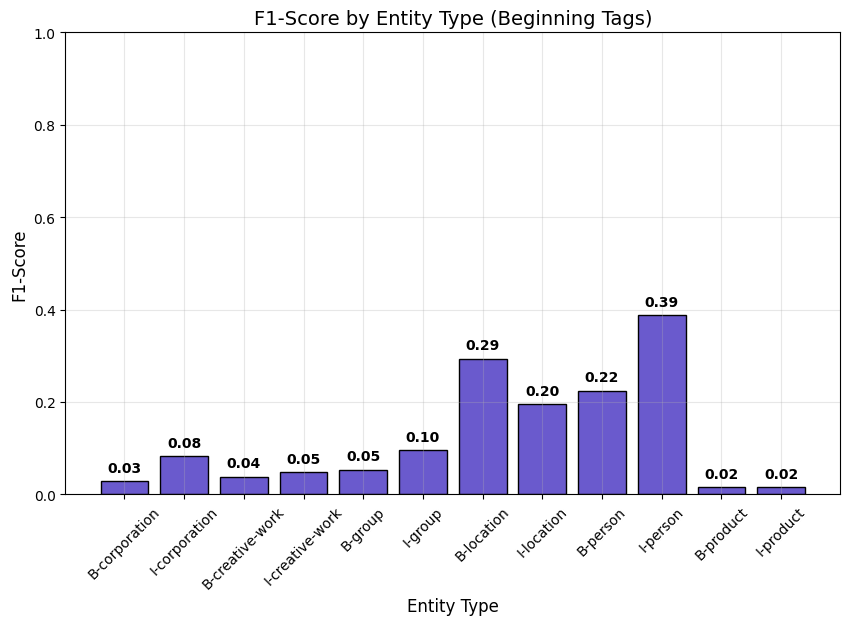

In [ ]:
# Extract metrics programmatically for visualization
report_dict = metrics.flat_classification_report(
    y_test, y_pred, labels=labels_to_evaluate, output_dict=True
)

# Extract B- labels for summary plot
entities = ENTITY_LABELS
f1_scores = [report_dict[ent]['f1-score'] for ent in entities]

plt.figure(figsize=(10, 6))
plt.bar(entities, f1_scores, color='slateblue', edgecolor='black')
plt.title("F1-Score by Entity Type (Beginning Tags)", fontsize=14)
plt.xlabel("Entity Type", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)
plt.ylim(0, 1.0)
plt.xticks(rotation=45)

# Add text labels on bars
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()


### Interpretation of Results

*   **Best Performers:** The model shows its highest F1-scores for `I-person` (0.387) and `B-location` (0.294). This suggests that persons (especially inside a multi-token name) and beginning of location entities might have more consistent patterns or distinctive features (like capitalization or specific word structures) that the model can pick up, or they are more frequently represented in the training data.

*   **Worst Performers:** The lowest F1-scores are observed for `B-product` (0.015), `I-product` (0.015), `B-corporation` (0.029), and `B-creative-work` (0.039). This indicates that the model struggles significantly with these entity types. Products, corporations, and creative works often lack clear distinguishing features, can be highly varied, or might be less frequent in the training data, making them harder for the model to correctly identify and classify. Their ambiguity or sparse representation likely contributes to the very poor performance.

## Error Analysis

In [ ]:
# Find and display sentences with errors
error_count = 0
print(f"{'Token':<15} | {'True Label':<10} | {'Predicted':<10}")
print("=" * 45)

for i in range(len(y_test)):
    if y_test[i] != y_pred[i]: # If there is a mismatch in the sentence
        for token, true_lbl, pred_lbl in zip(test_sentences[i], y_test[i], y_pred[i]):
            # Highlight errors with a little marker
            if true_lbl != pred_lbl:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10} <-- ERROR")
            else:
                print(f"{token:<15} | {true_lbl:<10} | {pred_lbl:<10}")
        print("-" * 45)
        error_count += 1

    if error_count >= 3: # Just show 3 erroneous sentences
        break


Token           | True Label | Predicted 
&               | O          | O         
gt              | O          | O         
;               | O          | O         
*               | O          | O         
The             | O          | O         
soldier         | O          | O         
was             | O          | O         
killed          | O          | O         
when            | O          | O         
another         | O          | O         
avalanche       | O          | O         
hit             | O          | O         
an              | O          | O         
army            | O          | O         
barracks        | O          | O         
in              | O          | O         
the             | O          | O         
northern        | O          | O         
area            | O          | O         
of              | O          | O         
Sonmarg         | B-location | O          <-- ERROR
,               | O          | O         
said            | O     

### Top 3 Error Patterns Observed in CRFs from Sample Output

Based on the displayed erroneous sentences from the test set, here are some key error patterns:

1.  **High Rate of False Negatives (Missing Entities):** The most striking pattern is the model's failure to identify various entities, frequently labeling them as 'O' (Outside) instead of their correct entity type. Examples include "Sonmarg" (True: `B-location`, Pred: `O`), "Waltengoo" (True: `B-location`, Pred: `O`), "Nar" (True: `I-location`, Pred: `O`), and "ART" (True: `B-group`, Pred: `O`). This suggests a primary struggle in detecting the very presence of an entity within the text.

2.  **Multi-word Entity Boundary Failures:** For entities spanning multiple words, the model often misses the entire span rather than just part of it. We observe "Waltengoo Nar" (True: `B-location I-location`, Pred: `O O`) and "Avalanche Rescue Teams" (True: `B-group I-group I-group`, Pred: `O O O`) being completely overlooked. This indicates a difficulty in recognizing continuous entity spans.

3.  **Challenges with Less Common or Contextually Ambiguous Entity Types:** The model appears to struggle particularly with entities like `B-group` and `I-group` (e.g., "Avalanche Rescue Teams", "ART"), which were completely missed in the sample errors. This could be due to their infrequent appearance in the training data, or their contextual similarity to non-entity phrases, making them harder to distinguish without richer contextual features.

## Business Recommendation: Enhancing Customer Support with NER

Implementing Named Entity Recognition (NER) in our customer support system offers significant advantages. By automatically identifying key entities like product names (`B-product`, `I-product`), customer names (`B-person`, `I-person`), locations (`B-location`, `I-location`), and issues (`B-group`, `I-group`) from incoming tickets, we can **automate ticket routing**. This ensures queries are sent to the correct department or specialist much faster, reducing response times and improving efficiency.

**Improved customer service** stems from quicker, more accurate resolutions. Agents receive pre-processed tickets, saving time on initial analysis and allowing them to focus on solving the core problem. This leads to higher customer satisfaction.

**Current System Limitations:** Our current model shows very low F1-scores for several critical entity types, especially products, corporations, and creative works (0.015-0.039). This means it frequently misses identifying these entities, leading to misrouting or requiring manual intervention.

**Possible Improvements:** To overcome these limitations, we must invest in more targeted training data, focusing on our specific product catalog and common customer issues. Additionally, exploring advanced models like transformer-based architectures (e.g., BERT, RoBERTa) or refining feature engineering for our CRF model will significantly boost accuracy, unlocking the full potential of NER for a truly optimized customer support experience.